In [1]:
# Forest Fire Burned Area Prediction using Neural Networks

Objective:
To predict the burned area of forest fires
using Artificial Neural Networks and environmental variables.

In [2]:
# Run only if TensorFlow is not installed

!pip install tensorflow

In [3]:
# Import Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Load dataset
df = pd.read_csv("D:/Goutham/Projects/Python//Project 7/Neural Network - Assignment 7/forestfires.csv")

df.head()

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,small
1,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,small
2,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,small
3,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,small
4,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,small


In [5]:
# Understanding the data
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          517 non-null    object 
 1   day            517 non-null    object 
 2   FFMC           517 non-null    float64
 3   DMC            517 non-null    float64
 4   DC             517 non-null    float64
 5   ISI            517 non-null    float64
 6   temp           517 non-null    float64
 7   RH             517 non-null    int64  
 8   wind           517 non-null    float64
 9   rain           517 non-null    float64
 10  area           517 non-null    float64
 11  dayfri         517 non-null    int64  
 12  daymon         517 non-null    int64  
 13  daysat         517 non-null    int64  
 14  daysun         517 non-null    int64  
 15  daythu         517 non-null    int64  
 16  daytue         517 non-null    int64  
 17  daywed         517 non-null    int64  
 18  monthapr  

(517, 31)

In [6]:
# Checking null values
df.isnull().sum()

month            0
day              0
FFMC             0
DMC              0
DC               0
ISI              0
temp             0
RH               0
wind             0
rain             0
area             0
dayfri           0
daymon           0
daysat           0
daysun           0
daythu           0
daytue           0
daywed           0
monthapr         0
monthaug         0
monthdec         0
monthfeb         0
monthjan         0
monthjul         0
monthjun         0
monthmar         0
monthmay         0
monthnov         0
monthoct         0
monthsep         0
size_category    0
dtype: int64

In [9]:
# Encode Categorical Variables
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,dayfri,...,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed,size_category_small
0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,1,...,False,False,False,False,False,False,False,False,False,True
1,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0,...,False,True,False,False,False,False,False,True,False,True
2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0,...,False,True,False,False,True,False,False,False,False,True
3,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,1,...,False,False,False,False,False,False,False,False,False,True
4,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0,...,False,False,False,False,False,True,False,False,False,True


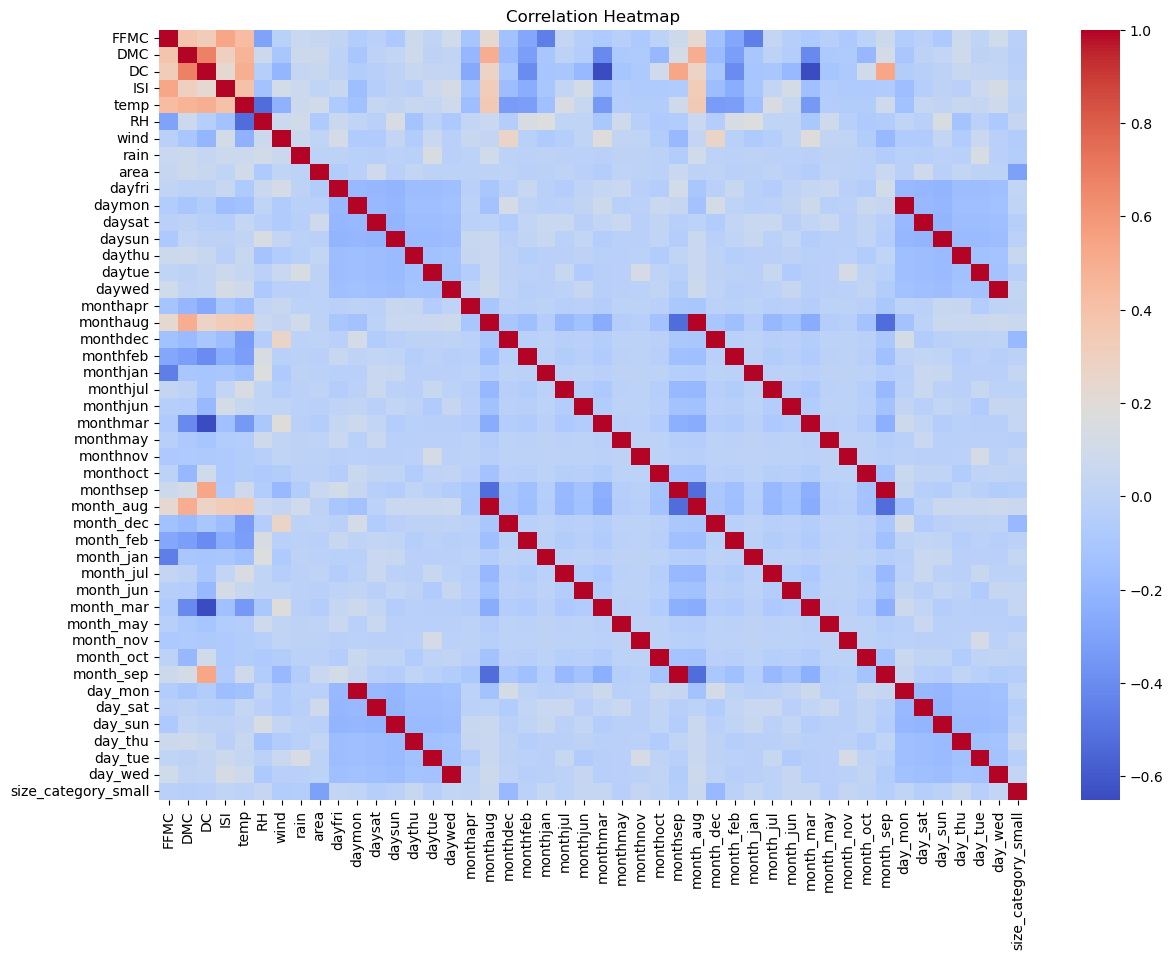

In [10]:
# Exploratory Data Analysis

# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

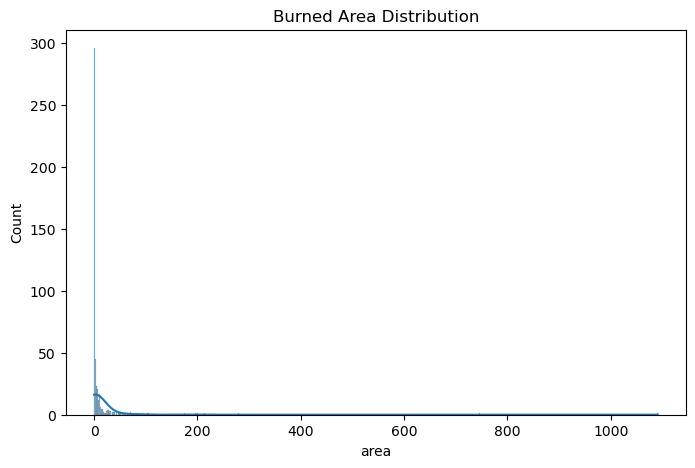

In [11]:
# Area Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['area'],
    kde=True
)

plt.title("Burned Area Distribution")

plt.show()

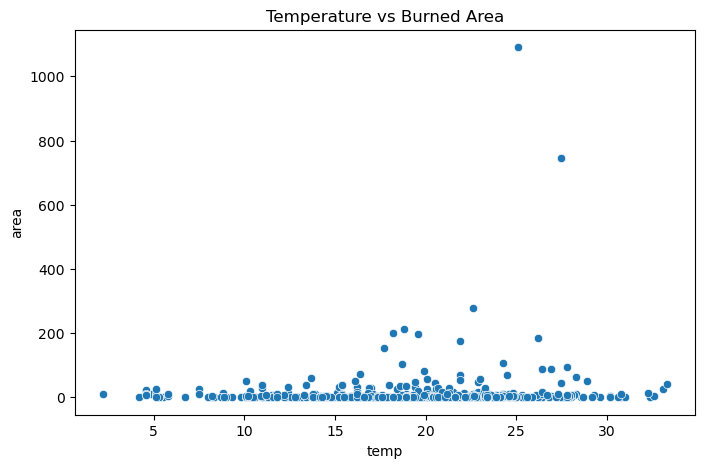

In [14]:
# Temperature vs Area
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['temp'],
    y=df['area']
)

plt.title("Temperature vs Burned Area")

plt.show()

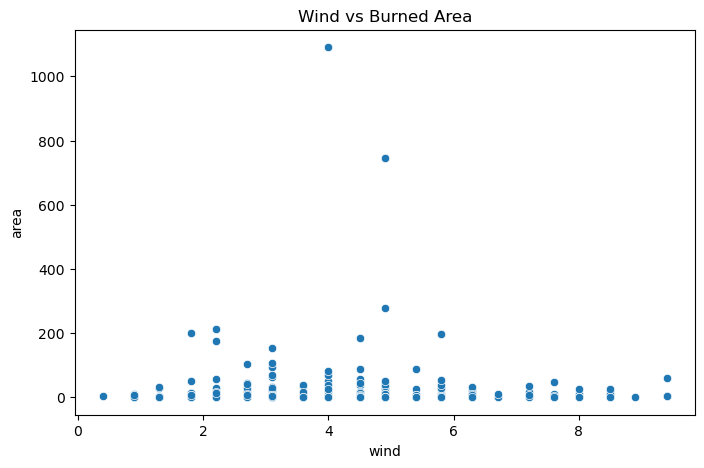

In [15]:
# Wind vs Area
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['wind'],
    y=df['area']
)

plt.title("Wind vs Burned Area")

plt.show()

EDA Insights:

- Burned area varies significantly across observations.
- Temperature and wind may influence fire spread.
- Seasonal variables may impact forest fire behavior.
- The dataset contains non-linear environmental relationships.

The target variable 'area' showed high skewness.

A logarithmic transformation was applied to improve
model learning and stabilize variance.

In [31]:
# Define X and y
X = df.drop('area', axis=1)

y = np.log1p(df['area'])

In [32]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Feature scaling is important because Neural Networks
are sensitive to feature magnitudes.

In [34]:
# Building the model
model = Sequential()

In [35]:
# Input & Hidden layer 1
model.add(
    Dense(
        32,
        input_dim=X_train.shape[1],
        activation='relu'
    )
)

C:\Users\scare\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# Hidden layer 2
model.add(
    Dense(
        16,
        activation='relu'
    )
)

In [38]:
# Hidden layer 3
model.add(
    Dense(
        8,
        activation='relu'
    )
)

In [39]:
# Output layer
model.add(
    Dense(
        1,
        activation='linear'
    )
)

In [40]:
# Model Summmary 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,417 (9.44 KB)

 Trainable params: 2,417 (9.44 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mse'
)

In [42]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 2.7972 - val_loss: 1.9371
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.3982 - val_loss: 1.7230
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.0839 - val_loss: 1.6004
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.8884 - val_loss: 1.5468
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.7515 - val_loss: 1.5026
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.6361 - val_loss: 1.4456
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.5276 - val_loss: 1.3856
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.4323 - val_loss: 1.3232
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.3318 - val_loss: 1.2452
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2312 - val_loss: 1.1755
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1318 - val_loss: 1.1147
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

In [43]:
# Predictions
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 


In [44]:
# R2 Score
r2_score(y_test, y_pred)

0.5136958711981738

In [45]:
# Root Mean Square Error
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

rmse

np.float64(1.033841940143417)

# Model Improvement:

The original ANN model showed weak predictive performance
due to the highly skewed distribution of burned area values.

Applying log transformation significantly improved:
- model stability
- prediction accuracy
- learning efficiency

This demonstrates the importance of preprocessing
in deep learning workflows.

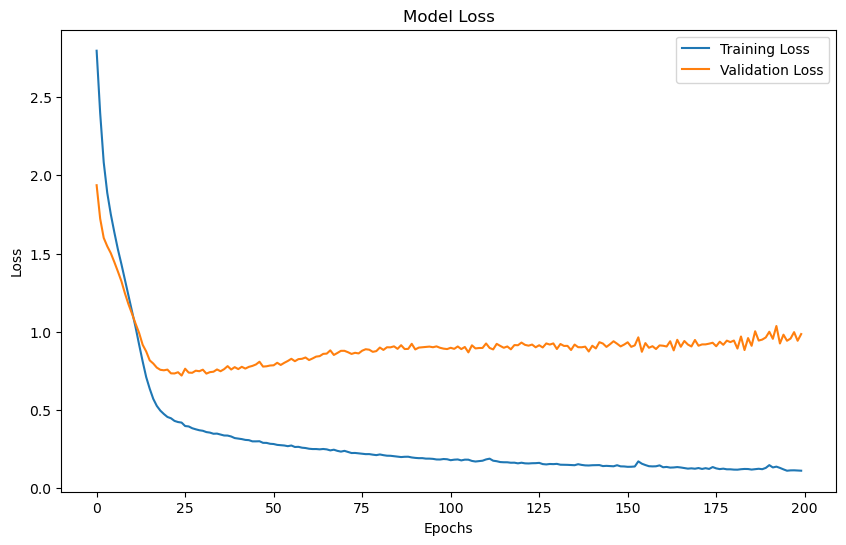

In [47]:
# Loss Curve
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

The loss curve shows how the Neural Network improves
during training.

Decreasing loss indicates better learning performance.

Artificial Neural Networks (ANN) are capable of learning
complex non-linear environmental relationships.

This makes them suitable for wildfire prediction problems.

Forest fire prediction is inherently difficult due to:
- environmental randomness
- non-linear fire behavior
- skewed burned area distribution

Neural Networks help capture complex relationships,
but wildfire prediction remains a challenging problem.

Business / Environmental Insights:

- Temperature and wind conditions influence fire spread.
- Neural Networks help model complex wildfire behavior.
- Predictive systems can support early fire risk analysis.

Impact:
- Supports wildfire management
- Helps disaster preparedness
- Assists environmental monitoring
- Improves resource planning

# Final Conclusion:

An Artificial Neural Network model was successfully developed
to predict the burned area of forest fires.

Initial model performance was limited due to the skewed
distribution of the target variable.

Applying logarithmic transformation significantly improved
the Neural Network performance and learning capability.

The project demonstrates how deep learning techniques
combined with proper preprocessing can support:
- wildfire prediction
- environmental analytics
- disaster management systems
- predictive environmental monitoring